1. Carga de Datos:

Importar las librerías necesarias (pandas, json, matplotlib.pyplot, seaborn, etc.).
Cargar el archivo corpus.json que guarda los títulos y contenidos de los artículos. Convertirlo en un DataFrame.

In [3]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Importar las funciones de análisis desde analyzer.py
from src.analyzer import analizar_sentimiento, identificar_entidades, modelar_temas
from src.preprocessor import procesar_texto  # Necesario para el modelado de temas
from src.utils import cargar_configuracion, obtener_valor_configuracion

config = cargar_configuracion()
stopwords_excluir_config = obtener_valor_configuracion(config.get('preprocesamiento', {}), 'stopwords_excluir', [])
cargar_stopwords_config = obtener_valor_configuracion(config.get('preprocesamiento', {}), 'cargar_stopwords_desde_archivo', False)
ruta_stopwords_config = obtener_valor_configuracion(config.get('preprocesamiento', {}), 'ruta_archivo_stopwords', 'data/stopwords_personalizadas.txt')


In [5]:
try:
    with open('corpus.json', 'r', encoding='utf-8') as f:
        corpus = json.load(f)
    df_corpus = pd.DataFrame(corpus)
    print("Corpus cargado correctamente.")
    print(df_corpus.head())
except FileNotFoundError:
    print("Error: No se encontró el archivo corpus.json. Asegúrate de haber ejecutado el script principal.")
except json.JSONDecodeError:
    print("Error: Problema al decodificar el archivo corpus.json.")

Corpus cargado correctamente.
                             titulo  \
0  On supporting science journalism   
1  On supporting science journalism   
2  On supporting science journalism   
3  On supporting science journalism   
4  On supporting science journalism   

                                           contenido  
0  AI chatbots called “griefbots” or “deadbots” o...  
1  This Impossible New Color Is So Rare That Only...  
2  Beyond XX and XY: The Extraordinary Complexity...  
3  The Nontoxic Cleaner That Kills Germs Better T...  
4  This Cutting-Edge Encryption Originates in Ren...  


2. Análisis Básico del Corpus:

Mostrar el número de artículos extraídos.
Ver la longitud promedio de los contenidos de los artículos.
Explorar la distribución de la longitud de los títulos y contenidos (histogramas).


Número de artículos: 5
Longitud promedio del contenido: 10932.80 caracteres.


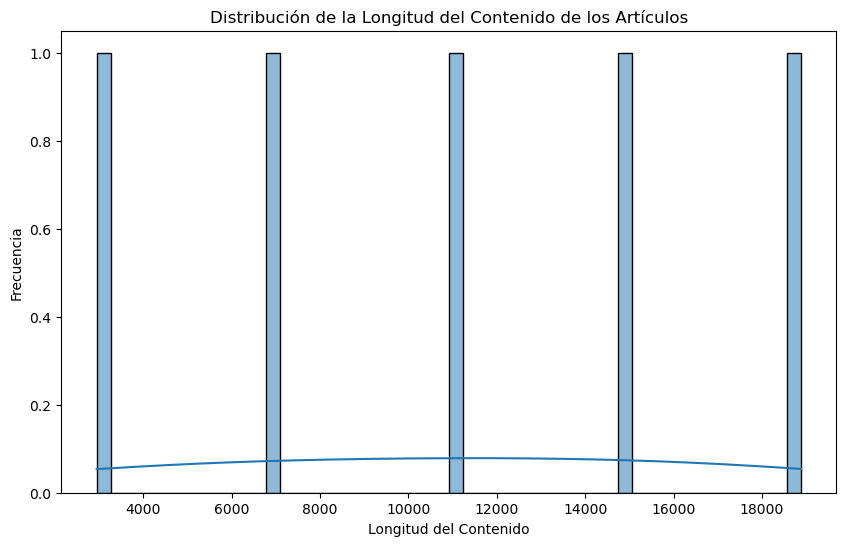

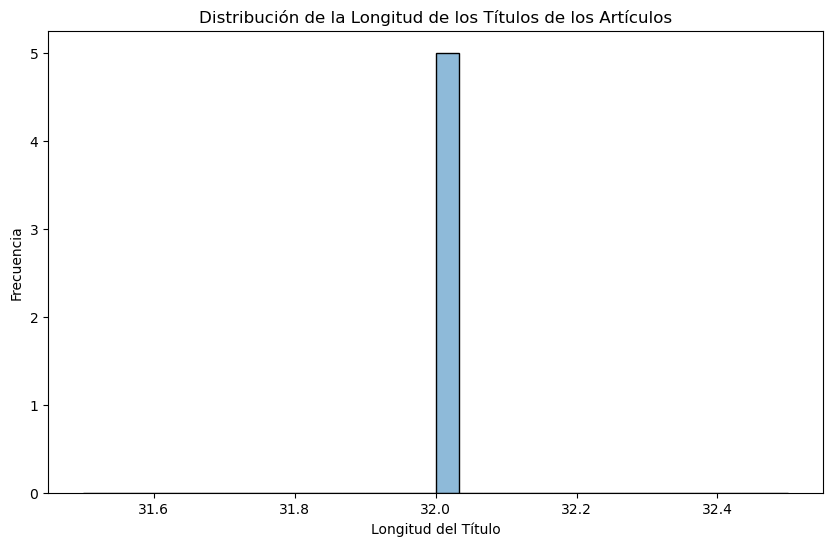

In [6]:
if 'contenido' in df_corpus:
    df_corpus['longitud_contenido'] = df_corpus['contenido'].apply(len)
    print(f"\nNúmero de artículos: {len(df_corpus)}")
    print(f"Longitud promedio del contenido: {df_corpus['longitud_contenido'].mean():.2f} caracteres.")

    plt.figure(figsize=(10, 6))
    sns.histplot(df_corpus['longitud_contenido'], bins=50, kde=True)
    plt.title('Distribución de la Longitud del Contenido de los Artículos')
    plt.xlabel('Longitud del Contenido')
    plt.ylabel('Frecuencia')
    plt.show()

if 'titulo' in df_corpus:
    df_corpus['longitud_titulo'] = df_corpus['titulo'].apply(len)
    plt.figure(figsize=(10, 6))
    sns.histplot(df_corpus['longitud_titulo'], bins=30, kde=True)
    plt.title('Distribución de la Longitud de los Títulos de los Artículos')
    plt.xlabel('Longitud del Título')
    plt.ylabel('Frecuencia')
    plt.show()

3. Análisis de Frecuencia de Palabras (Inicial):

Importar las funciones de preprocesamiento (limpiar_texto, procesar_texto) desde src.preprocessor.
Aplicar el preprocesamiento a una muestra de los contenidos.
Calcular la frecuencia de las palabras usando collections.Counter.
Mostrar las palabras más comunes.

In [7]:
from collections import Counter
from src.preprocessor import limpiar_texto, procesar_texto

if 'contenido' in df_corpus:
    muestra_contenido = df_corpus['contenido'].sample(min(10, len(df_corpus))).tolist()
    todos_los_tokens = []
    for texto in muestra_contenido:
        texto_limpio = limpiar_texto(texto)
        tokens = procesar_texto(texto_limpio)
        todos_los_tokens.extend(tokens)

    frecuencia = Counter(todos_los_tokens)
    print("\nPalabras más frecuentes:")
    print(frecuencia.most_common(20))


Palabras más frecuentes:
[('acid', 51), ('hypochlorous', 49), ('not', 32), ('use', 31), ('product', 22), ('idea', 21), ('work', 21), ('technology', 21), ('people', 20), ('scientific', 20), ('point', 19), ('s', 19), ('american', 19), ('like', 19), ('curve', 18), ('world', 18), ('new', 18), ('thing', 17), ('need', 17), ('time', 16)]


4. Pruebas de Visualización:

Importar la función crear_nube_palabras_redonda desde src.analyzer.
Generar nubes de palabras con diferentes parámetros (max_words, colormap) para una muestra del corpus procesado.


Nube de palabras (muestra):


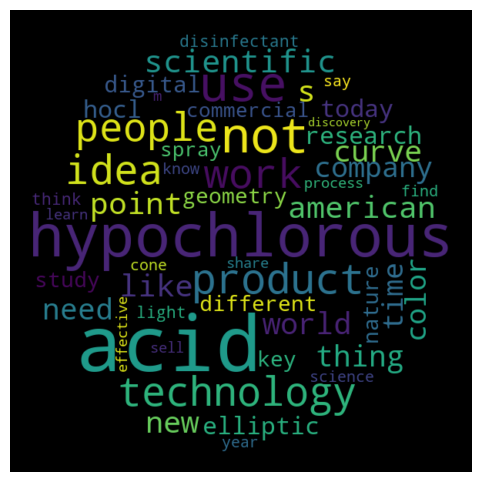

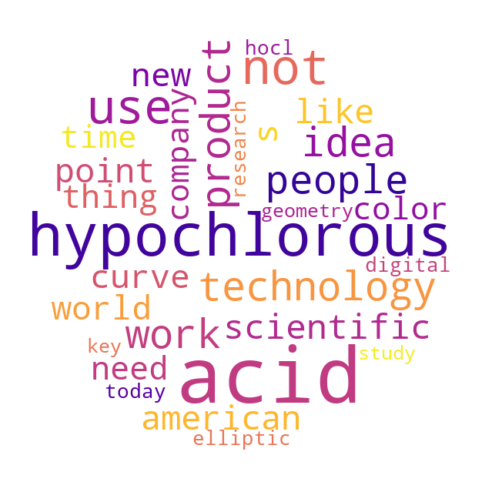

In [8]:
from src.analyzer import crear_nube_palabras_redonda

if frecuencia:
    print("\nNube de palabras (muestra):")
    crear_nube_palabras_redonda(dict(frecuencia.most_common(50)), num_palabras=50, colormap='viridis')
    crear_nube_palabras_redonda(dict(frecuencia.most_common(30)), num_palabras=30, background_color='white', colormap='plasma')

In [9]:
corpus_articulos = df_corpus.to_dict('records')

5. Análisis de Sentimiento

Analizar el sentimiento de los artículos y visualizar la distribución de la polaridad.

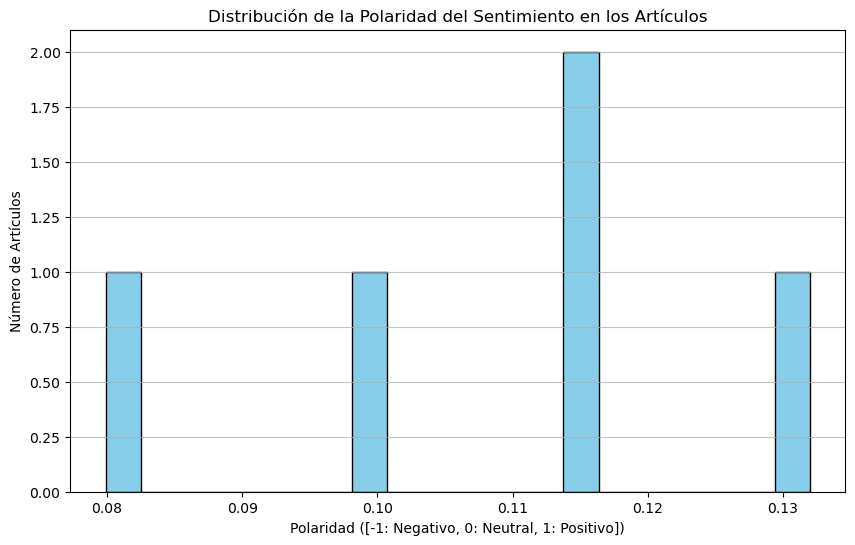

In [10]:
if corpus_articulos:
    polaridades = []
    for articulo in corpus_articulos:
        polaridad, subjetividad = analizar_sentimiento(articulo['contenido'])
        polaridades.append(polaridad)

    plt.figure(figsize=(10, 6))
    plt.hist(polaridades, bins=20, color='skyblue', edgecolor='black')
    plt.title('Distribución de la Polaridad del Sentimiento en los Artículos')
    plt.xlabel('Polaridad ([-1: Negativo, 0: Neutral, 1: Positivo])')
    plt.ylabel('Número de Artículos')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("No hay artículos en el corpus para analizar el sentimiento.")

6. Reconocimiento de Entidades Nombradas (NER)

Mostrar ejemplos de las entidades nombradas encontradas en algunos artículos.

In [11]:
if corpus_articulos:
    print("\nEjemplo de Entidades Nombradas en los Artículos:")
    for i, articulo in enumerate(corpus_articulos[:5]):  # Mostrar las entidades de los primeros 5 artículos
        entidades = identificar_entidades(articulo['contenido'])
        print(f"\nArtículo {i+1} (Título: {articulo['titulo'][:50]}...):")
        if entidades:
            for entidad, tipo in entidades:
                print(f"- Entidad: {entidad}, Tipo: {tipo}")
        else:
            print("- No se encontraron entidades.")
else:
    print("No hay artículos en el corpus para identificar entidades.")


Ejemplo de Entidades Nombradas en los Artículos:

Artículo 1 (Título: On supporting science journalism...):
- Entidad: AI, Tipo: ORG
- Entidad: ByRachel Feltman, Tipo: PERSON
- Entidad: Naeem Amarsy, Tipo: PERSON
- Entidad: Fonda Mwangi&Alex, Tipo: PERSON
- Entidad: Sugiura, Tipo: GPE
- Entidad: Anaissa, Tipo: GPE
- Entidad: Rachel Feltman, Tipo: PERSON
- Entidad: Rachel Feltman, Tipo: PERSON
- Entidad: 2013, Tipo: DATE
- Entidad: AI, Tipo: ORG
- Entidad: Amazon Prime’s, Tipo: ORG
- Entidad: the decade or, Tipo: DATE
- Entidad: today, Tipo: DATE
- Entidad: today, Tipo: DATE
- Entidad: Katarzyna Nowaczyk-Basińska, Tipo: PERSON
- Entidad: the Leverhulme Center for the Future of Intelligence, Tipo: ORG
- Entidad: the University of Cambridge, Tipo: ORG
- Entidad: today, Tipo: DATE
- Entidad: KatarzynaNowaczyk-Basińska, Tipo: ORG
- Entidad: first, Tipo: ORDINAL
- Entidad: Nowaczyk-Basińska, Tipo: PERSON
- Entidad: first, Tipo: ORDINAL
- Entidad: Eterni.me, Tipo: FAC
- Entidad: almost a dec

7. Modelado de Temas
Preprocesar el corpus y probar diferentes números de temas, visualizando las palabras clave por tema.

In [ ]:
if corpus_articulos:
    corpus_procesado = []
    for articulo in corpus_articulos:
        texto_limpio = articulo['contenido'] 
        tokens = procesar_texto(texto_limpio,
                                stopwords_excluir=stopwords_excluir_config,
                                ruta_archivo_stopwords=ruta_stopwords_config,
                                cargar_stopwords_desde_archivo=cargar_stopwords_config)
        corpus_procesado.append(tokens)

    if corpus_procesado:
        print("\nModelado de Temas:")
        num_temas_a_probar = [3, 5, 7]  # prueba con diferentes números de temas según necesidad
        num_palabras_por_tema = obtener_valor_configuracion(config.get('analisis', {}).get('modelado_temas', {}), 'num_palabras_por_tema', 10)

        for num_temas in num_temas_a_probar:
            temas = modelar_temas(corpus_procesado, num_temas=num_temas, num_palabras_por_tema=num_palabras_por_tema)
            print(f"\nNúmero de Temas: {num_temas}")
            for tema_id, palabras in temas:
                print(f"  Tema #{tema_id+1}: {palabras}")
    else:
        print("No se pudo procesar el corpus para el modelado de temas.")
else:
    print("No hay artículos en el corpus para el modelado de temas.")


Modelado de Temas:

Número de Temas: 3
  Tema #1: 0.023*"acid" + 0.022*"hypochlorous" + 0.009*"product" + 0.007*"use" + 0.007*"hocl" + 0.006*"disinfectant" + 0.006*"spray" + 0.006*"covid" + 0.006*"effective" + 0.005*"bottle"
  Tema #2: 0.010*"curve" + 0.009*"color" + 0.009*"point" + 0.007*"elliptic" + 0.007*"cone" + 0.007*"key" + 0.007*"geometry" + 0.006*"light" + 0.005*"say" + 0.005*"ng"
  Tema #3: 0.012*"feltman" + 0.011*"technology" + 0.010*"basińska" + 0.009*"nowaczyk" + 0.008*"digital" + 0.006*"use" + 0.006*"idea" + 0.006*"like" + 0.006*"think" + 0.006*"need"

Número de Temas: 5
  Tema #1: 0.001*"color" + 0.001*"acid" + 0.001*"light" + 0.001*"thing" + 0.001*"use" + 0.001*"hypochlorous" + 0.001*"feltman" + 0.001*"cone" + 0.001*"olo" + 0.001*"like"
  Tema #2: 0.001*"hypochlorous" + 0.001*"acid" + 0.001*"technology" + 0.001*"use" + 0.001*"basińska" + 0.001*"feltman" + 0.001*"like" + 0.001*"curve" + 0.001*"nowaczyk" + 0.001*"need"
  Tema #3: 0.020*"acid" + 0.019*"hypochlorous" + 0.00